# Лабораторная работа
## Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

### Паспорт работы

| Поле | Значение |
|---|---|
| ФИО студента | Стрельченко Алексей Александрович|
| Группа | БАС-21 |
| Дата выполнения | 20.09.2026|
| Номер варианта | 3 |


### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |


### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

$$
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}},
$$

где $M$ — маска области патча, $p$ — его содержимое, $T_\theta$ — преобразование при параметрах
съёмки $\theta$ (ракурс, дистанция, освещение, оптика, обработка изображения).

Требование робастности возмущения формализует Expectation over Transformation:

$$
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big].
$$

**Задание 0.** Заполните таблицу различий трёх постановок (ячейки со знаком «?»):

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | 	Пиксели входного тензора (все или большинство) | Ограниченная область на поверхности знака | Текстура/принт на деформируемой ткани |
| Ограничение возмущения | ≤ε | Форма и площадь маски M, физическая реализуемость цвета | Маска + растяжимость, складки, не-жёсткость |
| Обязательные члены \(\mathcal{D}\) | Обычно отсутствуют или лёгкий шум | 	Ракурс, дистанция, освещение, оптика, шум сенсора | Всё из знака + складки, изгиб, смена позы, динамика |
| Основная сложность | Незаметность возмущения | Сохранение эффекта при смене ракурса/дистанции | Не-жёсткие деформации и движение человека |
| Типичная метрика | ASR при фиксированном ε | ASR в физических условиях, robust ASR | ASR на видеопоследовательности, устойчивость во времени |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [3]:
# TODO A.1: подставьте значения своего варианта из таблицы вариантов
SEED = 123
RES = 20
FREQ = 1.5

RES = 20×20 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.956


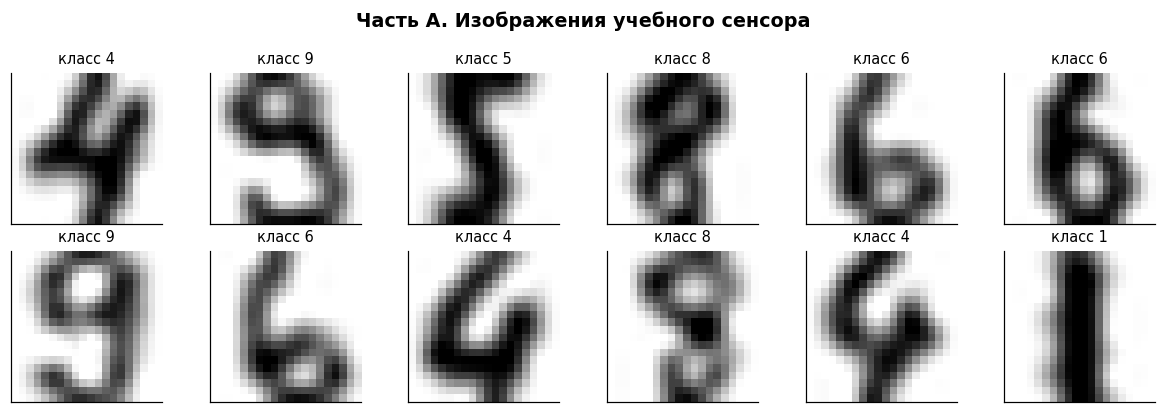

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

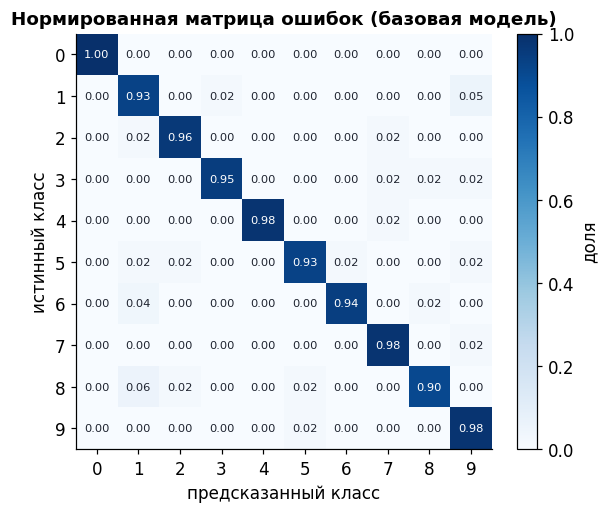

In [5]:
# TODO A.3: постройте нормированную матрицу ошибок базовой модели.
# Подсказка: confusion_matrix(..., normalize="true"), затем imshow с colorbar.

cm = confusion_matrix(y_test, baseline.predict(flat(X_test_img)), normalize="true")

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс")
ax.set_title("Нормированная матрица ошибок (базовая модель)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if cm[i, j] > 0.5 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.046, label="доля")
ax.grid(False)
plt.tight_layout()
plt.show()

**Отчёт по части A.** Заполните:

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` | 123 / 20 |
| Размер обучающей выборки | 1257 |
| Базовая точность `acc_clean` | 0.956 |
| Две пары классов с наибольшей путаницей | 1(ист) и 9(пред), 8(ист) и 1(пред)|

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: По acc_clean нельзя судить о пригодности модели к физическим объектам. Метрика измеряется на неискажённых, центрированных, нормированных изображениях одного домена. Она не учитывает ракурс, дистанцию, освещение, шум сенсора, окклюзии и деформации. Модель с высокой acc_clean может деградировать до случайного уровня при малейшем сдвиге условий съёмки

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [6]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [7]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # B.1 контраст
    out = (out - 0.5) * contrast + 0.5
    # B.2 яркость
    out = out * brightness
    # B.3 размытие
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)
    # B.4 шум сенсора
    if noise > 0:
        out = out + gen.normal(0, noise, out.shape)
    # B.5 окклюзия
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out[r0:r1, c0:c1] = value

    return np.clip(out, 0.0, 1.0).astype(np.float32)

B.6 Истинный класс: 7

Режим          Предсказание  P(истинного)  Метка изменилась?
--------------------------------------------------------------
Исходное                  7        0.8107                нет
Поворот                   4        0.0877                 да
Дистанция                 4        0.1572                 да
Слабый свет               4        0.2736                 да
Blur + шум                8        0.2315                 да
Окклюзия                  9        0.1470                 да

B.7 Число режимов со сменой метки: 5 (требуется не менее 2)


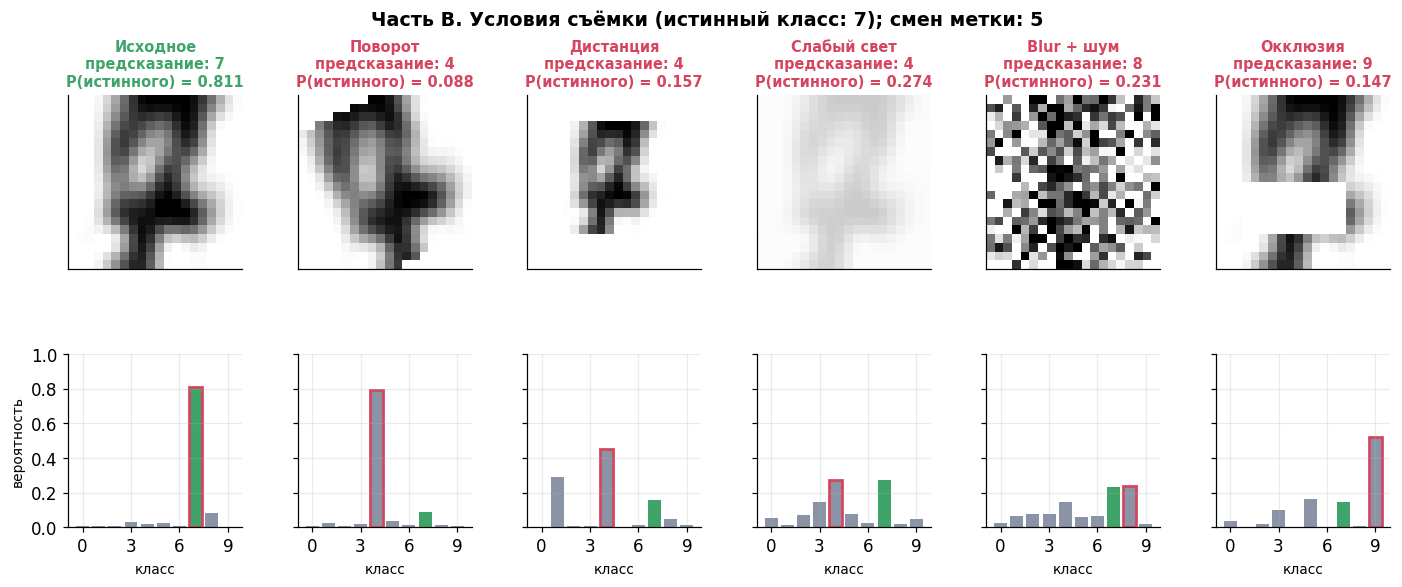

In [31]:
# TODO B.6: выберите объект-пример и подберите параметры так, чтобы МИНИМУМ два режима
# приводили к смене предсказанной метки. Значения ниже — стартовые, их нужно изменить.
idx = 9
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",    dict()),
    ("Поворот",     dict(angle=26)),
    ("Дистанция",   dict(scale=0.65)),
    ("Слабый свет", dict(brightness=0.22, contrast=0.86)),
    ("Blur + шум",  dict(blur=2.8, noise=0.53)),
    ("Окклюзия",    dict(occlusion=(RES // 2, RES // 2 + RES // 3, RES // 5 - 1, RES - 5, 0.0))),
]

# --- 1) Сначала считаем всё и печатаем таблицу ДО графиков ---
rows = []
views = []
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba))
    p_true = float(proba[true_label])
    ok = pred == true_label
    rows.append((name, pred, p_true, ok))
    views.append(view)

print(f"B.6 Истинный класс: {true_label}\n")
print(f"{'Режим':<14} {'Предсказание':>12} {'P(истинного)':>13} {'Метка изменилась?':>18}")
print("-" * 62)
for name, pred, p_true, ok in rows:
    print(f"{name:<14} {pred:>12} {p_true:>13.4f} {'да' if not ok else 'нет':>18}")

flips = sum(1 for *_, ok in rows if not ok)
print(f"\nB.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

# --- 2) Теперь рисуем графики (используем уже посчитанные views) ---
fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
for col, (name, pred, p_true, ok) in enumerate(rows):
    view = views[col]
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}\nP(истинного) = {p_true:.3f}",
                           fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                            color=[PALETTE["robust"] if k == true_label else PALETTE["gray"]
                                   for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: в моём эксперименте сильнее всего сработал поворот (P(истинного) = 0.0877), за ним окклюзия (0.1470). Однако значения параметров в режимах разные, поэтому корректное сравнение требует выравнивания силы искажений.

Для другого объекта ответ может быть иным. У тонких цифр (1, 7) сильнее всего ломает поворот, у «плотных» с петлями (0, 8) — окклюзия и размытие. Так что самый разрушительный фактор зависит от того, на какие признаки опирается модель для конкретной цифры.

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [32]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    if size is None:
        size = max(3, RES // 3)
    result = image.copy()
    mask = np.zeros_like(image, dtype=np.float32)
    r1 = min(top + size, image.shape[0])
    c1 = min(left + size, image.shape[1])
    result[top:r1, left:c1] = value
    mask[top:r1, left:c1] = 1.0
    return result, mask

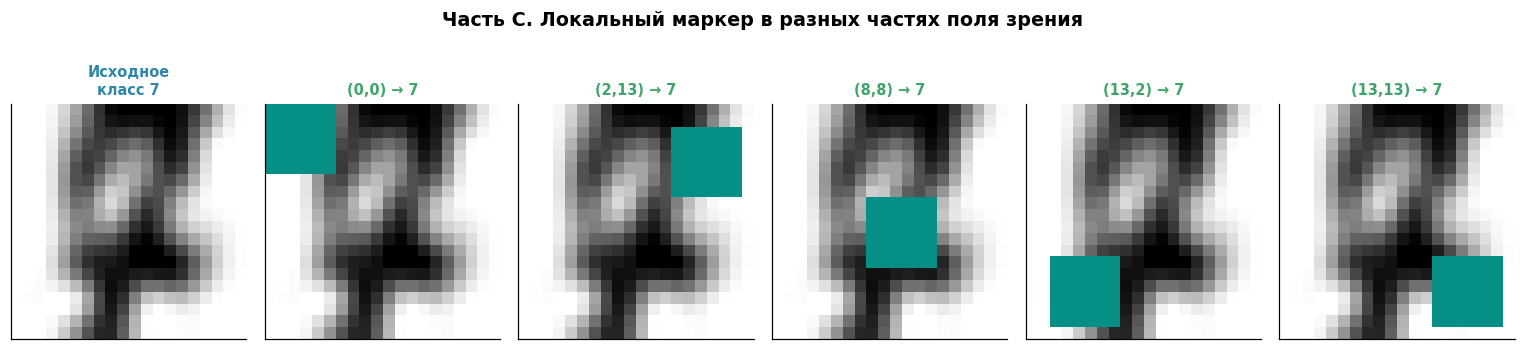

In [33]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [ ]:
# TODO C.2: заполните карту точности pos_map по позициям маркера на всей тестовой выборке.
# TODO C.3: заполните списки area_acc и area_frac для кривой деградации по площади.

MARKER = max(3, RES // 3)       
stride = max(1, RES // 8)          
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))

for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        marked = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked)))

sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    if s == 0:
        marked = X_test_img
    else:
        top = (RES - s) // 2
        marked = np.asarray([apply_marker(im, top, top, s)[0] for im in X_test_img])
    area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked))))
    area_frac.append(100.0 * s * s / RES ** 2)

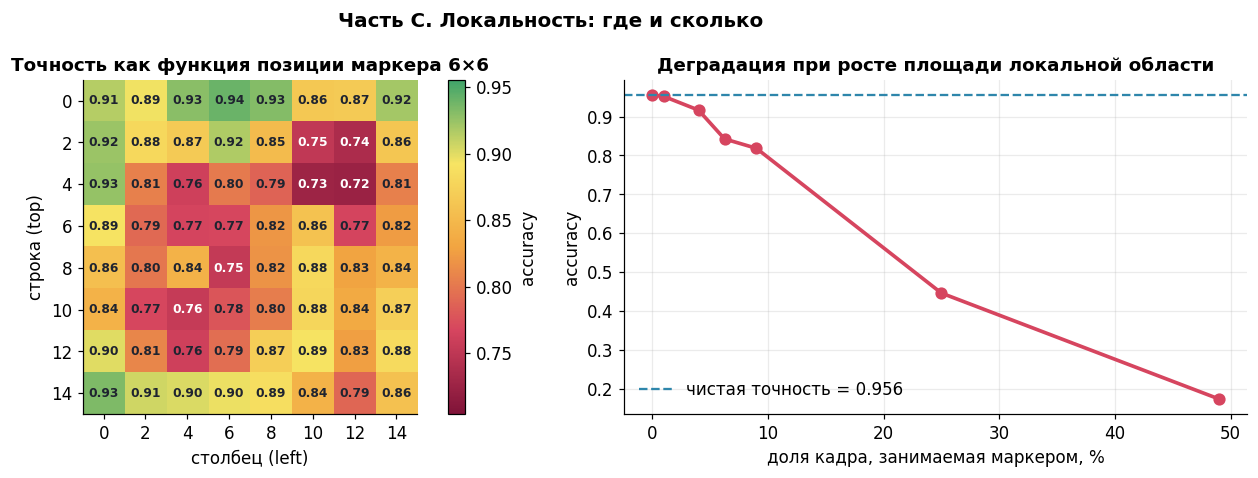

C.4 Худшая позиция: (4, 12) → accuracy 0.724
C.5 Лучшая позиция: accuracy 0.941; разница 0.217


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

**Отчёт по части C.**

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 6 |
| Худшая позиция и её accuracy | (4,12) acc: 0.724|
| Лучшая позиция и её accuracy | (0, 6) acc: 0.941 |
| Разница между худшей и лучшей позицией | 0.217 |
| Площадь, при которой accuracy падает ниже 0.5, % | 25% и выше |

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: При одинаковой площади результат зависит от положения, потому что логистическая регрессия опирается на конкретные пиксели-признаки. Центр цифры несёт максимум информации о классе (там сосредоточены штрихи, пересечения, изгибы), а углы и края — почти неинформативны. Маркер в центре затирает самые важные признаки и резко снижает точность; маркер в углу перекрывает фон и почти не влияет на решение. Это иллюстрирует, что «локальность» атаки определяется не только площадью, но и семантической значимостью области.



## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [37]:
def sample_params(gen, severity=1.0):
    return dict(
        angle      = gen.uniform(-17, 17) * severity,
        scale      = 1.0 + gen.uniform(-0.17, 0.13) * severity,
        brightness = 1.0 + gen.uniform(-0.26, 0.20) * severity,
        contrast   = 1.0 + gen.uniform(-0.20, 0.20) * severity,
        blur       = max(0.0, gen.uniform(0.0, 0.85) * severity),
        noise      = max(0.0, gen.uniform(0.0, 0.055) * severity),
    )

def transformed_dataset(imgs, gen, severity=1.0):
    return np.asarray([
        physical_transform(im, **sample_params(gen, severity), generator=gen)
        for im in imgs
    ])

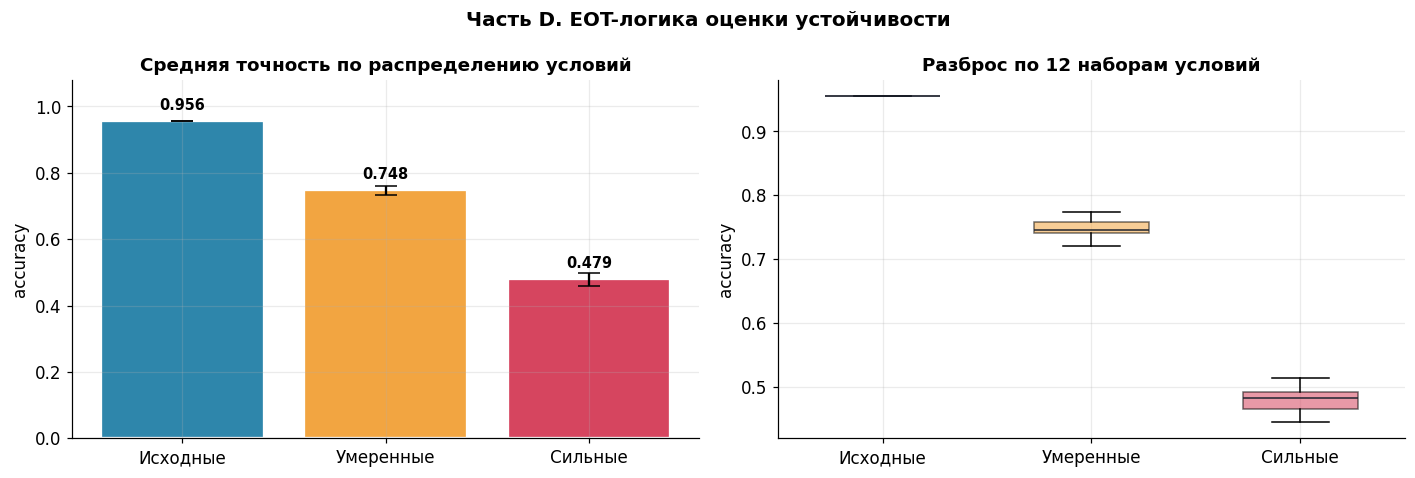

D.3 Исходные   accuracy = 0.956 ± 0.000
D.3 Умеренные  accuracy = 0.748 ± 0.014
D.3 Сильные    accuracy = 0.479 ± 0.020


In [38]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.956 | 0.000 | 0 |
| Умеренные | 0.748 | 0.014 | 0.208 |
| Сильные | 0.479 | 0.020 | 0.477 |

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ: Оценка по одному кадру завышает устойчивость, потому что один кадр — это одна реализация  θ∼D. Если случайно выпали «лёгкие» условия, точность будет высокой, но это не характеризует поведение модели в среднем. EOT (математическое ожидание по преобразованиям) усредняет точность по 12 независимым наборам условий и даёт несмещённую оценку. Связь severity и стандартного отклонения прямая: чем шире диапазон параметров (больше severity), тем разнороднее условия в разных прогонах, тем больше разброс accuracy.

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [39]:
# TODO E.1: задайте углы согласно своему варианту
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 6, 12, 18, 24]

# TODO E.2: заполните матрицу grid: строки — углы, столбцы — масштабы
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([
            physical_transform(im, angle=a, scale=s, brightness=0.95,
                               blur=0.25, generator=gen)
            for im in X_test_img
        ])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

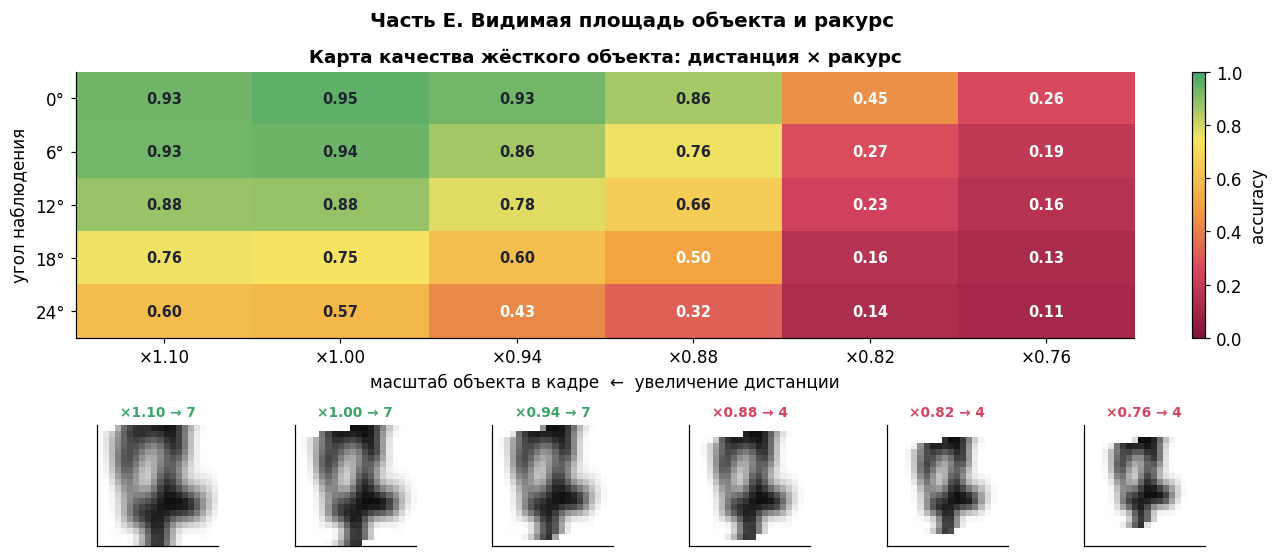

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     6°: ×1.10, ×1.00, ×0.94, ×0.88
    12°: ×1.10, ×1.00, ×0.94
    18°: ×1.10, ×1.00
    24°: нет


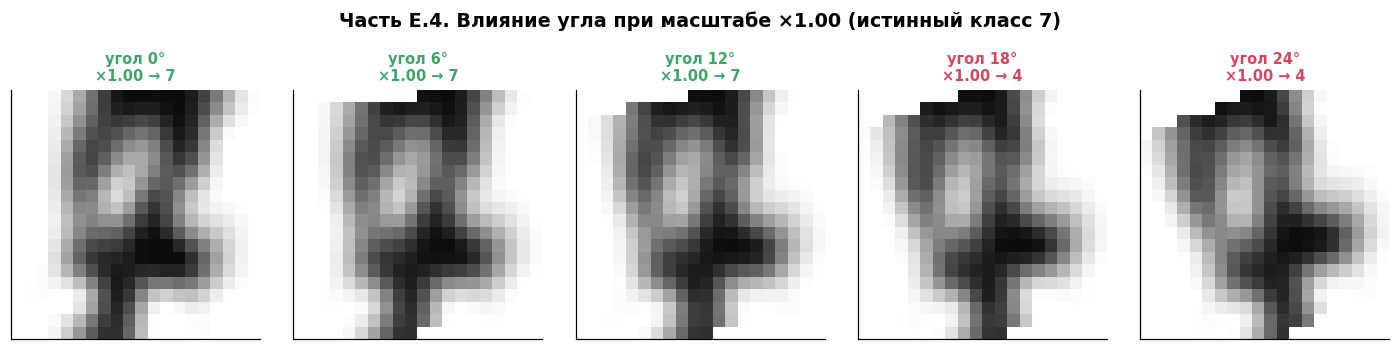

/tmp/ipykernel_2338/3227540868.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


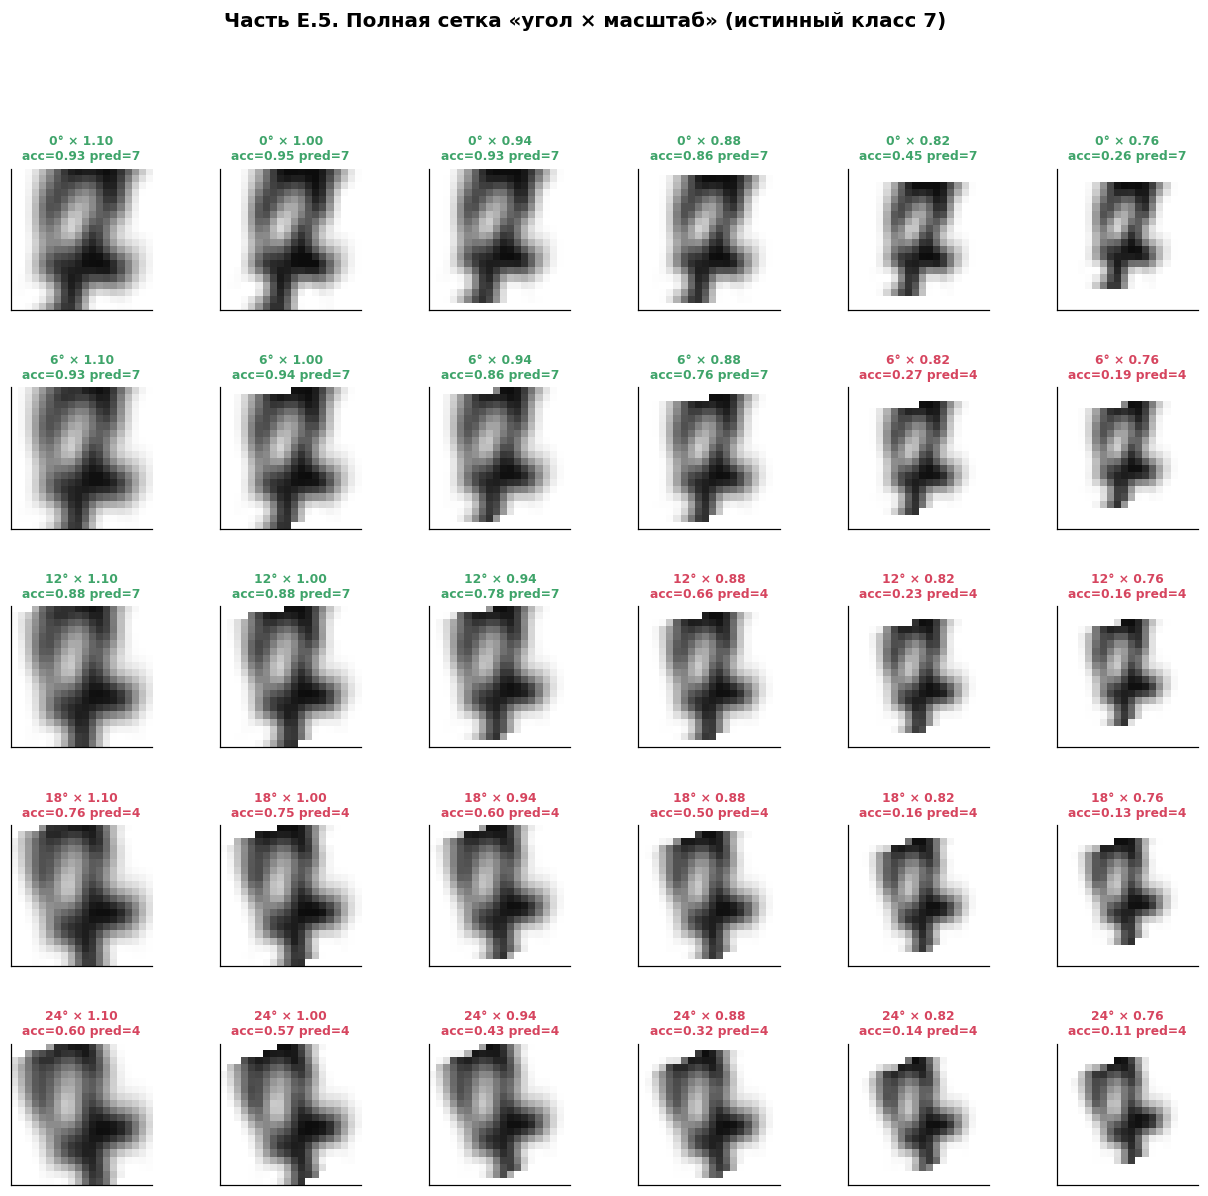

E.6 Детализация по углам и масштабам:

 угол | ×1.10 | ×1.00 | ×0.94 | ×0.88 | ×0.82 | ×0.76
--------------------------------------------------------
  0°  |  0.93 |  0.95 |  0.93 |  0.86 |  0.45 |  0.26
  6°  |  0.93 |  0.94 |  0.86 |  0.76 |  0.27 |  0.19
 12°  |  0.88 |  0.88 |  0.78 |  0.66 |  0.23 |  0.16
 18°  |  0.76 |  0.75 |  0.60 |  0.50 |  0.16 |  0.13
 24°  |  0.60 |  0.57 |  0.43 |  0.32 |  0.14 |  0.11

Первый угол, при котором accuracy < 0.70 при всех масштабах: 24°
Наименьший масштаб с accuracy >= 0.70 хотя бы при одном угле: ×0.88


In [43]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")
    
# ============================================================
# E.4. Один пример на каждый угол (масштаб фиксирован)
# ============================================================
fixed_scale_for_angles = 1.00
fig, axes = plt.subplots(1, len(angles), figsize=(2.6 * len(angles), 3.0))
if len(angles) == 1:
    axes = [axes]
for ax, a in zip(axes, angles):
    view = physical_transform(example, angle=a, scale=fixed_scale_for_angles,
                              brightness=0.95, blur=0.25,
                              generator=np.random.default_rng(SEED + int(a)))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"угол {a}°\n×{fixed_scale_for_angles:.2f} → {pred}",
                 fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle(f"Часть E.4. Влияние угла при масштабе ×{fixed_scale_for_angles:.2f} "
             f"(истинный класс {true_label})",
             fontsize=12.5, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


# ============================================================
# E.5. Полная сетка «угол × масштаб»
# ============================================================
fig, axes = plt.subplots(len(angles), len(scales),
                         figsize=(2.4 * len(scales), 2.4 * len(angles)),
                         gridspec_kw={"hspace": 0.55, "wspace": 0.15})
if len(angles) == 1:
    axes = axes[None, :]
if len(scales) == 1:
    axes = axes[:, None]

for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        ax = axes[i, j]
        view = physical_transform(example, angle=a, scale=s, brightness=0.95,
                                  blur=0.25,
                                  generator=np.random.default_rng(SEED + 7))
        pred = int(baseline.predict(flat(view[None, ...]))[0])
        show_img(ax, view)
        acc_ij = grid[i, j]
        ax.set_title(f"{a}° × {s:.2f}\nacc={acc_ij:.2f} pred={pred}",
                     fontsize=8, fontweight="bold",
                     color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle(f"Часть E.5. Полная сетка «угол × масштаб» (истинный класс {true_label})",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


# ============================================================
# E.6. Числовая сводка: что происходит на границах
# ============================================================
print("E.6 Детализация по углам и масштабам:\n")
print(f"{'угол':>5} | " + " | ".join(f"×{s:.2f}" for s in scales))
print("-" * (8 + 8 * len(scales)))
for i, a in enumerate(angles):
    row = " | ".join(f"{grid[i, j]:5.2f}" for j in range(len(scales)))
    print(f"{a:>3}°  | {row}")

# граница применимости: первый угол, где accuracy < 0.70 при любом масштабе
first_bad_angle = next((a for i, a in enumerate(angles)
                        if all(grid[i, j] < 0.70 for j in range(len(scales)))), None)
# минимальный масштаб, при котором accuracy >= 0.70 хотя бы при одном угле
min_ok_scale = None
for j, s in enumerate(scales):
    if any(grid[i, j] >= 0.70 for i in range(len(angles))):
        min_ok_scale = s  # берём последний (самый маленький) подходящий
print(f"\nПервый угол, при котором accuracy < 0.70 при всех масштабах: "
      f"{first_bad_angle}°" if first_bad_angle is not None else
      "\nВсе углы имеют хотя бы один масштаб с accuracy >= 0.70")
print(f"Наименьший масштаб с accuracy >= 0.70 хотя бы при одном угле: ×{min_ok_scale:.2f}")

**Отчёт по части E.**

| Показатель | Ваше значение |
|---|---|
| Углы варианта | 0°, 6°, 12°, 18°, 24° |
| Максимальная accuracy в карте | 0.95 (0°, ×1.00) |
| Минимальная accuracy в карте | 0.11 (24°, ×0.76) |
| Наибольший допустимый угол при accuracy ≥ 0.70 | 18° |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 | ×0.88  |

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ: Чем меньше знак занимает места в кадре, тем хуже модель его распознаёт. А уменьшить видимую площадь можно двумя способами: отойти подальше (уменьшить масштаб) или посмотреть под углом (увеличить ракурс). Оба фактора работают в одну сторону — чем меньше пикселей остаётся на сам знак, тем меньше информации о нём получает модель. А раз информации мало, то любому искажению — патчу, шуму, размытию — становится проще «перевесить» полезный сигнал. Поэтому успех физической атаки напрямую связан с тем, насколько маленьким и наклонённым выглядит объект в кадре.  

При этом ракурс оказался важнее дистанции. Если смотреть на знак прямо, можно отойти довольно далеко и модель ещё справляется. Но если посмотреть на тот же знак под большим углом, модель ошибается даже вплотную. Причина в том, что поворот не просто уменьшает картинку — он меняет её форму. Знак сжимается по одной оси, пропорции штрихов искажаются, линии рвутся. А уменьшение масштаба лишь равномерно «размывает» ту же самую форму, не меняя её структуру. Модель, обученная на прямых изображениях, к искажению формы чувствительнее, чем к потере чёткости.  

Ещё одна важная деталь — деградация происходит не плавно, а обрывом. Пока объект достаточно крупный и прямой, модель держится уверенно. Но стоит чуть-чуть перейти границу — и точность падает сразу и сильно, а не постепенно. Это значит, что у модели есть порог, после которого она разваливается. Для атаки это удобно: не нужно идеально подбирать условия, достаточно немного перейти через порог.  

--  

Классификатор решает простую задачу: ему показали картинку, он говорит, что на ней. У него на выходе — один набор вероятностей по классам. Атака на классификатор меняет ровно одну метку.  

Детектор в конвейере автономного вождения решает задачу сложнее. Он должен найти объект в кадре, обвести его рамкой (bounding box), назвать класс и оценить уверенность. То есть на выходе у него не одно число, а целая структура: где, что и насколько уверенно. Атака на детектор должна сломать сразу всё это: либо заставить его не найти знак вообще, либо сдвинуть рамку так, чтобы она накрыла другой объект, либо подменить класс, не тронув остальные детекции в кадре. Это гораздо сложнее, потому что нужно согласованно испортить несколько выходов одновременно.  

К тому же детектор смотрит на изображение на нескольких масштабах (чтобы находить и близкие, и далёкие объекты) и использует контекст — соседние объекты, общую сцену. Патч, который сбивает простой классификатор, может вообще не подействовать на детектор. И наоборот: чтобы обмануть детектор, патч должен работать на нескольких уровнях разрешения и не выглядеть подозрительно на фоне сцены. Поэтому атака на детектор — отдельная, более трудная задача, чем атака на классификатор.


## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [44]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c],
                             order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [45]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

# TODO F.4: заполните warp_acc (деформация ткани) и rigid_acc (жёсткий поворот на a * 6 градусов)
warp_acc, rigid_acc = [], []
for a in amps:
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))
    rotated = np.asarray([
        physical_transform(im, angle=a * 6.0, generator=np.random.default_rng(SEED))
        for im in X_test_img
    ])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rotated))))

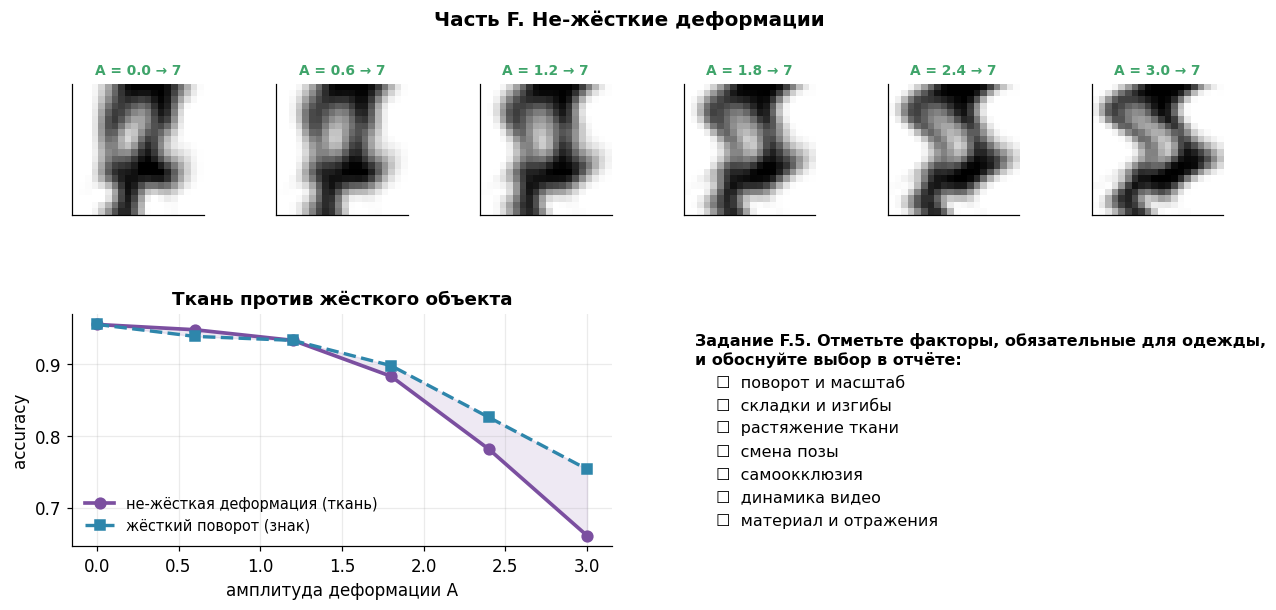

F.6 accuracy при максимальной деформации: ткань 0.661 против жёсткого поворота 0.754

F.7 Сводная таблица части F:
    A |    ткань |  жёсткий поворот |  разница
----------------------------------------------
  0.0 |    0.956 |            0.956 |   +0.000
  0.6 |    0.948 |            0.939 |   +0.009
  1.2 |    0.933 |            0.933 |   +0.000
  1.8 |    0.883 |            0.898 |   -0.015
  2.4 |    0.781 |            0.826 |   -0.044
  3.0 |    0.661 |            0.754 |   -0.093


In [48]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

# ============================================================
# F.7. Таблица для отчёта
# ============================================================
print("\nF.7 Сводная таблица части F:")
print(f"{'A':>5} | {'ткань':>8} | {'жёсткий поворот':>16} | {'разница':>8}")
print("-" * 46)
for a, w, r in zip(amps, warp_acc, rigid_acc):
    print(f"{a:>5.1f} | {w:>8.3f} | {r:>16.3f} | {w - r:>+8.3f}")

Из списка обязательны для состязательной одежды все семь факторов: поворот и масштаб (базовые условия съёмки), складки и изгибы (ткань не плоская), растяжение ткани (трикотаж деформируется на теле), смена позы (человек двигается), самоокклюзия (руки, сумки, другие объекты перекрывают принт), динамика видео (одежда наблюдается в потоке кадров, а не в одном изображении), материал и отражения (блеск, ворс, цвет при разном освещении). Для жёсткого знака эти члены D не нужны: знак плоский, не деформируется, не меняет позу и не движется. Ему достаточно ракурса, дистанции, освещения, оптики и шума сенсора.

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении \(\mathcal{D}\) по сравнению со знаком?

Ответ: Поворот и масштаб — это жёсткие преобразования, они описывают плоский недеформируемый объект. Для знака этого достаточно, но ткань не-жёсткая: она изгибается, образует складки, растягивается на теле, меняет форму при смене позы, частично перекрывается руками и сумками, существует в видеопотоке и по-разному отражает свет в зависимости от материала. Всё это не сводится к повороту и масштабу. Поэтому в распределение D для одежды добавляются новые члены: амплитуда и частота складок, поперечные смещения, растяжение, смена позы, самоокклюзия, динамика видео, свойства материала. Без учёта этих членов защита, обученная только на жёстких преобразованиях, развалится при первой же складке или смене позы.

## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [50]:
# TODO G.1: сформируйте аугментированную выборку: исходные данные + 4 копии со случайными
# условиями съёмки (severity ≈ 1.3) + 1 копия с деформацией ткани (amplitude 0.5–2.5).
aug_gen = np.random.default_rng(SEED + 5)

# 4 копии с физическими условиями severity ≈ 1.3
copies = [X_train_img]
for _ in range(4):
    copies.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))

# 1 копия с деформацией ткани
warped_train = np.asarray([
    cloth_warp(im, amplitude=aug_gen.uniform(0.5, 2.5)) for im in X_train_img
])
copies.append(warped_train)

X_aug = np.concatenate(copies, axis=0)
y_aug = np.concatenate([y_train] * len(copies), axis=0)

# TODO G.2: обучите модель robust с теми же гиперпараметрами, что у baseline
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

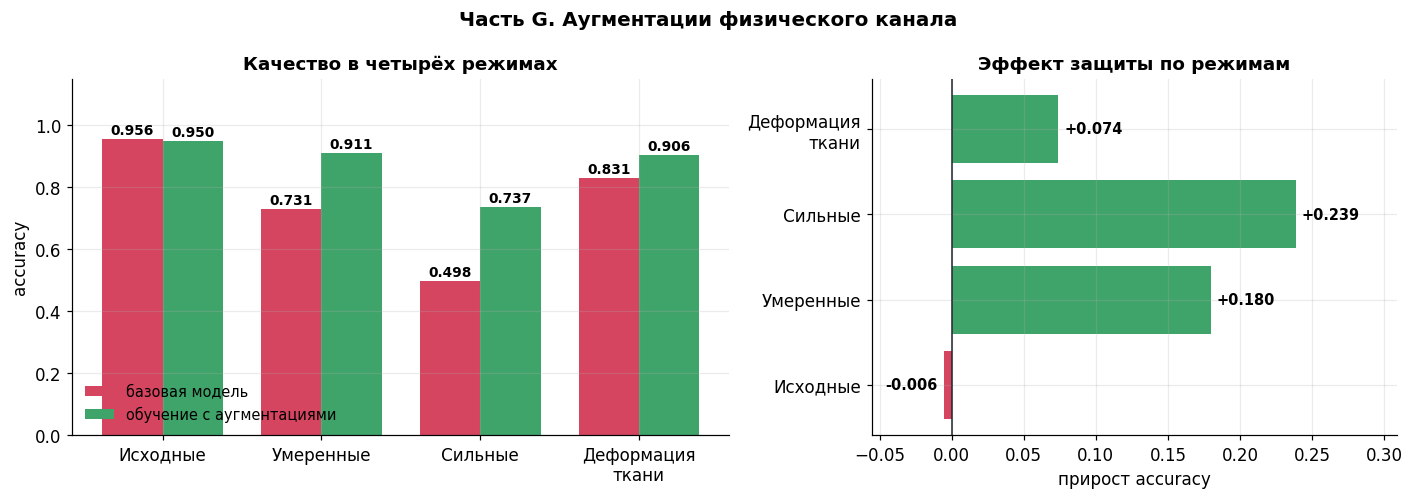

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.956 → защита 0.950 (-0.006)
    Умеренные          база 0.731 → защита 0.911 (+0.180)
    Сильные            база 0.498 → защита 0.737 (+0.239)
    Деформация ткани   база 0.831 → защита 0.906 (+0.074)


In [51]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ: Цена робастности в моём эксперименте составила всего 0.006 — это падение точности на чистых данных с 0.956 у базовой модели до 0.950 у модели с аугментациями, то есть меньше одного процентного пункта. Такой компромисс возникает потому, что модель не может быть идеальной одновременно на чистых и на искажённых картинках: базовая модель «запоминает» точные пиксели чистых изображений и поэтому отлично работает на них, но разваливается при малейшем повороте или шуме, а модель с аугментациями вынуждена учить более общие признаки, которые чуть менее точны на конкретном чистом кадре, зато устойчивы к искажениям. В обмен на эти 0.6 п.п. потери я получил большой выигрыш на искажённых данных, поэтому такой обмен очень выгоден.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [52]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# TODO H.1: сформируйте кадры: случайные условия severity ≈ 1.3, а на кадрах 9–14 добавьте окклюзию.
# TODO H.2: соберите probas (вероятности по кадрам) и per_frame_pred (покадровые решения).
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, severity=1.3)
    if 9 <= t <= 14:
        params["occlusion"] = occ_window
    frame = physical_transform(example, **params, generator=seq_gen)
    frames.append(frame)
    p = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(p)
    per_frame_pred.append(int(np.argmax(p)))


probas = np.asarray(probas)
# TODO H.3: вычислите накопленные решения cum_pred и уверенность cum_conf по средним вероятностям
cum_pred = [int(np.argmax(probas[:t + 1].mean(axis=0))) for t in range(FRAMES)]
cum_conf = [float(probas[:t + 1].mean(axis=0)[true_label]) for t in range(FRAMES)]
per_frame_conf = probas[:, true_label].tolist()

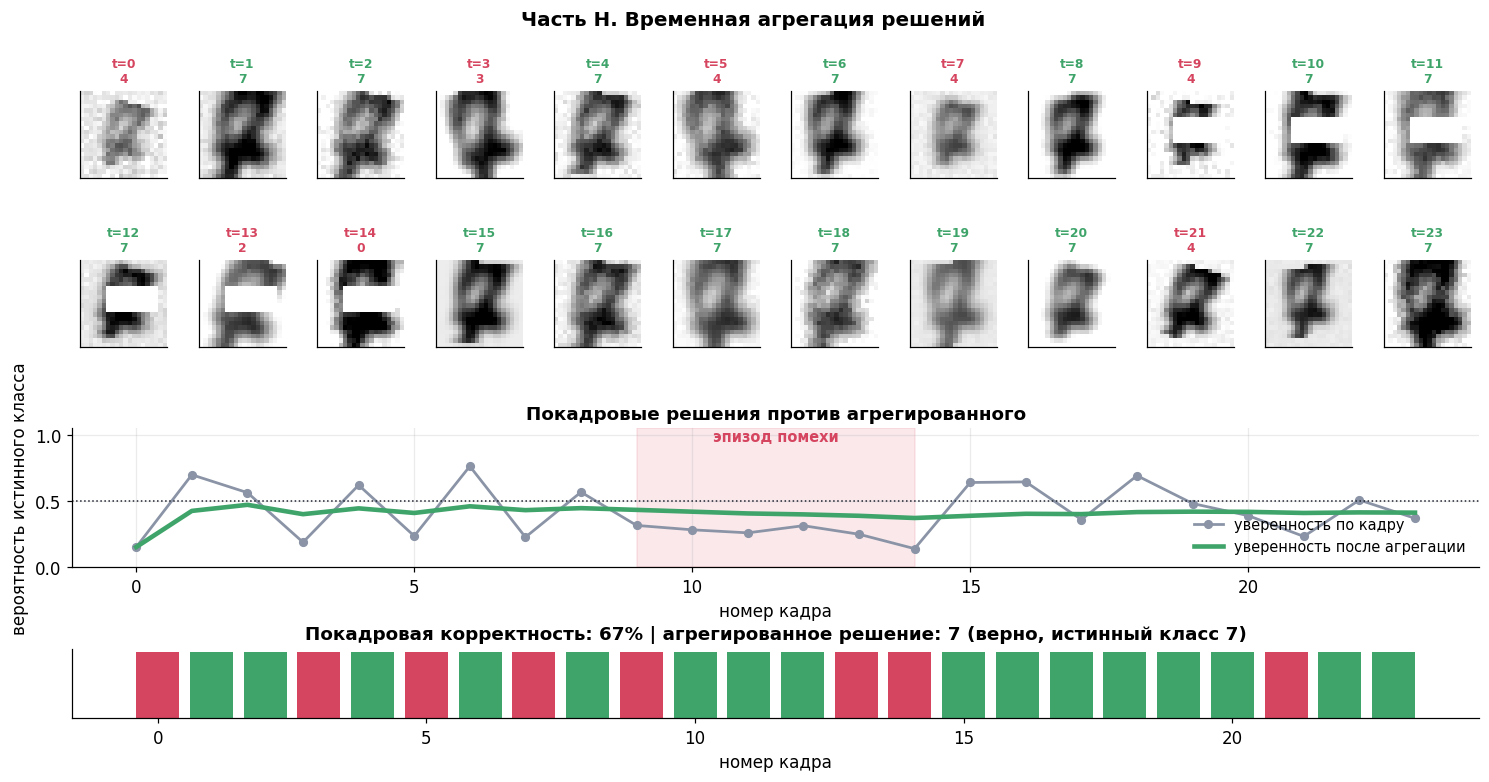

H.4 Покадровая корректность: 0.667
H.5 Агрегированное решение: 7 (истинный класс 7)
H.6 Агрегация стабильно верна начиная с кадра: 1


In [56]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(16.5, 7.4))
gs = fig.add_gridspec(4, 12,
                      height_ratios=[1.0, 1.0, 1.6, 0.8],
                      hspace=0.85, wspace=0.15)

# ряд 1: кадры 0..11
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t])
    ok = per_frame_pred[t] == true_label
    ax.set_title(f"t={t}\n{per_frame_pred[t]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

# ряд 2: кадры 12..23
for t in range(12, 24):
    ax = fig.add_subplot(gs[1, t - 12])
    show_img(ax, frames[t])
    ok = per_frame_pred[t] == true_label
    ax.set_title(f"t={t}\n{per_frame_pred[t]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

# ряд 3: график уверенности
ax1 = fig.add_subplot(gs[2, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"],
         linewidth=1.8, markersize=5, label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"],
         linewidth=3, label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5,
         color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса")
ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

# ряд 4: полоса корректности
ax2 = fig.add_subplot(gs[3, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")

fig.suptitle("Часть H. Временная агрегация решений",
             fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

In [54]:
votes = np.zeros((FRAMES, 10))
for t, p in enumerate(per_frame_pred):
    votes[t, p] = 1
cum_vote = [int(np.argmax(votes[:t + 1].sum(axis=0))) for t in range(FRAMES)]
stable_vote = next((t for t in range(FRAMES) if all(c == true_label for c in cum_vote[t:])), None)
print(f"H.7 Голосование: стабилизация с кадра {stable_vote}")

H.7 Голосование: стабилизация с кадра 2


**Отчёт по части H.**

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров | 0.667 |
| Итоговое агрегированное решение | 7 (верно, истинный класс 7) |
| Номер кадра, с которого агрегация стабильно верна | 1 |

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

Ответ: При усреднении вероятностей агрегация стабилизируется начиная с кадра 1, а при голосовании по большинству — с кадра 2. То есть усреднение вероятностей оказалось чуть быстрее: оно использует не только «победивший» класс каждого кадра, но и уверенность модели, поэтому уже на первом кадре даёт правильное решение и дальше его не меняет. Голосование по большинству смотрит только на метку, поэтому ему нужно накопить хотя бы два согласованных голоса — отсюда задержка на один кадр. Разница небольшая, но она показывает, что усреднение вероятностей — более информативный способ агрегации, чем простое голосование.

## Часть I. Итоговый анализ

### Сводная таблица результатов

| Режим | accuracy | Падение относительно `acc_clean` |
|---|---|---|
| Идеальные условия | 0.956 | — |
| Умеренные условия | 0.731 | 0.225 |
| Сильные условия | 0.498 | 0.458 |
| Локальный маркер, худшая позиция | 0.724 | 0.232 |
| Максимальная дистанция и ракурс | 0.110 | 0.846 |
| Максимальная деформация ткани | 0.661 | 0.295 |

### Выводы

Сформулируйте не менее пяти выводов, опираясь на числа из своих экспериментов:

1. Высокая точность на чистых данных не гарантирует физической устойчивости. Базовая модель показала 0.956 на идеальных изображениях, но упала до 0.498 при сильных искажениях и до 0.110 при максимальном ракурсе и дистанции — почти до случайного угадывания.

2. Ракурс критичнее дистанции, а положение области — важнее её площади. При повороте на 24° модель не работает ни при каком масштабе, тогда как при прямом взгляде держится даже при уменьшении объекта. Маркер в центре цифры снижает точность до 0.724, а такой же маркер в углу почти не влияет.

3. Деградация при уменьшении масштаба идёт обрывом, а не плавно. Между соседними масштабами точность падала сразу на несколько десятков процентных пунктов — у модели есть порог, после которого она резко теряет работоспособность.

4. Положение локальной области важнее её площади. Маркер в центре цифры снижал точность до 0.724, а такой же маркер в углу почти не влиял. Модель опирается на информативные пиксели в центре, а не на всю картинку равномерно.

5. Аугментации — эффективная и дешёвая защита. Они дали прирост до +0.239 в сильных условиях при цене всего 0.006 на чистых данных, то есть почти ничего не стоили на идеальных изображениях, но сильно помогли в тяжёлых условиях.

### Контрольные вопросы

1. Почему ограничение \(\|\delta\|_p \le \varepsilon\) недостаточно для описания физической атаки?  
Потому что оно описывает только цифровое возмущение пикселей. В реальности к нему добавляются ракурс, дистанция, освещение, оптика, шум сенсора, окклюзия и деформации. Атака должна сохранять эффект при всех этих преобразованиях, а не только при фиксированном δ.  

2. Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?  
ASR — доля успешных атак в идеальных цифровых условиях. Robust ASR — то же, но усреднённое по распределению физических преобразований. Robust ASR ниже, потому что часть атак «ломается» при смене ракурса, дистанции и освещения.

3. Как площадь и положение патча влияют на его эффективность? Приведите числа из части C.  
Площадь патча влияет на эффективность не напрямую, а через то, какие именно признаки модели он перекрывает. Если патч закрывает информативные пиксели — те, на которые модель опирается при распознавании, — точность падает сильно. Если тот же по площади патч попадает на малозначимую область, эффект почти незаметен. Поэтому при одинаковой площади результат сильно зависит от положения: патч в центре объекта ломает распознавание, а патч на краю или в углу почти не мешает. Иными словами, важна не столько площадь, сколько то, попадает ли патч на семантически значимую часть объекта.  

4. Почему атака на детектор объектов сложнее атаки на классификатор?  
Атака на классификатор меняет одну метку — этого достаточно. Атака на детектор должна заставить его ошибиться сразу по нескольким осям: потерять объект, сдвинуть рамку, перепутать класс или уверенность, не задев другие детекции. Детектор к тому же смотрит на несколько масштабов и использует контекст сцены, поэтому добиться устойчивого эффекта сложнее.  

5. Какие члены распределения \(\mathcal{D}\) обязательны для одежды и не нужны для жёсткого знака?  
Для одежды: складки и изгибы, растяжение ткани, смена позы, самоокклюзия, динамика видео, свойства материала и отражения. Для жёсткого знака достаточно ракурса, дистанции, освещения, оптики и шума сенсора.  

6. Почему временная агрегация помогает, но не является полной защитой?  
Она гасит случайные ошибки отдельных кадров, потому что они не коррелируют во времени. Но при согласованной помехе на всех кадрах (устойчивый патч, постоянная окклюзия) ошибки становятся коррелированными, и агрегация тоже обманывается.  

7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?  
Цена робастности — это падение точности на чистых данных после защиты. В моём эксперименте она составила 0.006. Нельзя ограничиваться одним режимом, потому что защита может давать прирост в одних условиях и потери в других; нужен профиль по всем режимам, чтобы увидеть полную картину.

### Дополнительные задания повышенной сложности

- Заменить `LogisticRegression` на `MLPClassifier` и повторить части D, E, G. Изменился ли характер деградации?
- Добавить в часть C маркер несимметричной формы (полоса) и сравнить с квадратом равной площади.
- Добавить в `cloth_warp` второе поперечное поле смещений с независимой частотой.
- Прогнать работу для двух дополнительных значений `SEED` и оценить устойчивость выводов.
- Реализовать простейший детектор аномальной локальной области и проверить его на данных части C.


Сетка accuracy (углы × масштабы):
 угол | ×0.50 | ×0.60 | ×0.70 | ×0.80 | ×0.90 | ×1.00 | ×1.10 | ×1.20
  0°  |  0.10 |  0.11 |  0.19 |  0.45 |  0.86 |  0.96 |  0.93 |  0.90
  5°  |  0.10 |  0.10 |  0.12 |  0.23 |  0.65 |  0.89 |  0.93 |  0.89
 10°  |  0.10 |  0.10 |  0.14 |  0.33 |  0.77 |  0.91 |  0.92 |  0.89
 15°  |  0.10 |  0.10 |  0.16 |  0.33 |  0.71 |  0.91 |  0.91 |  0.88
 20°  |  0.10 |  0.10 |  0.16 |  0.33 |  0.66 |  0.86 |  0.88 |  0.86
 25°  |  0.10 |  0.10 |  0.12 |  0.24 |  0.54 |  0.80 |  0.86 |  0.85
 30°  |  0.10 |  0.10 |  0.11 |  0.17 |  0.41 |  0.72 |  0.83 |  0.84
 35°  |  0.10 |  0.10 |  0.11 |  0.18 |  0.36 |  0.58 |  0.76 |  0.80
 40°  |  0.10 |  0.10 |  0.11 |  0.16 |  0.31 |  0.46 |  0.65 |  0.74
 45°  |  0.10 |  0.10 |  0.10 |  0.16 |  0.36 |  0.49 |  0.55 |  0.61
 50°  |  0.10 |  0.10 |  0.10 |  0.10 |  0.16 |  0.34 |  0.50 |  0.51
 55°  |  0.10 |  0.10 |  0.10 |  0.10 |  0.11 |  0.27 |  0.37 |  0.39
 60°  |  0.10 |  0.10 |  0.10 |  0.10 |  0.10 |  0.15 | 

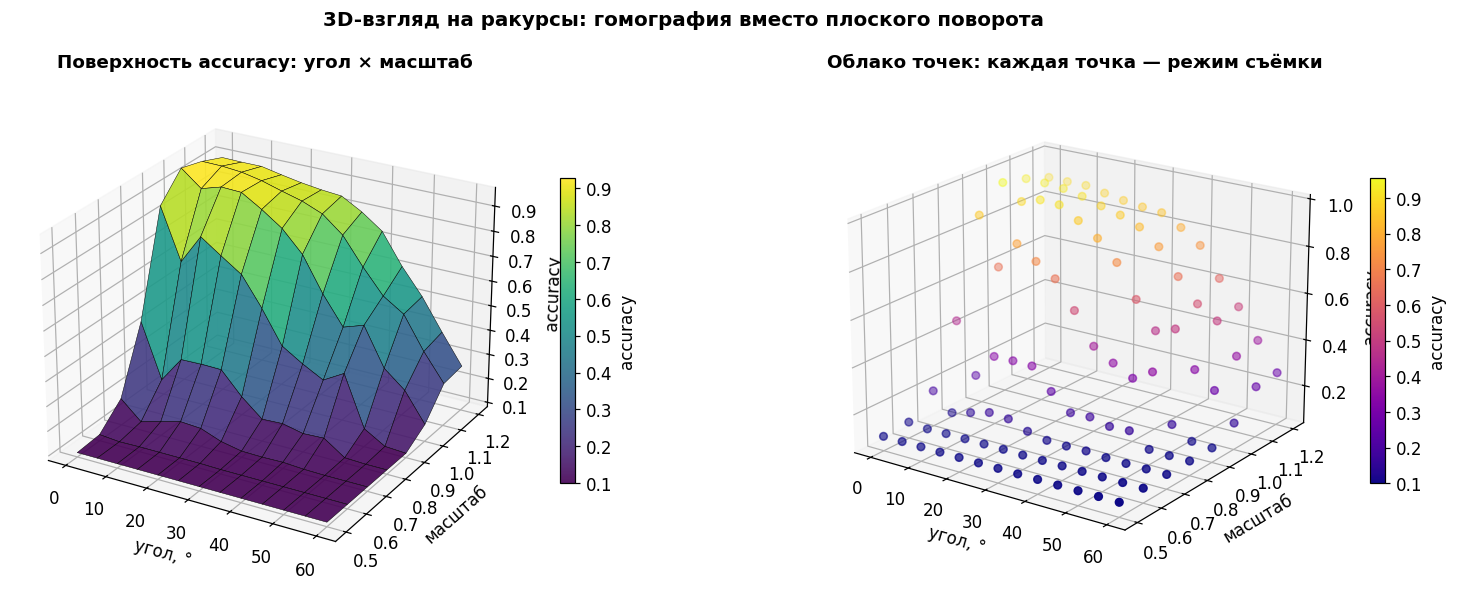

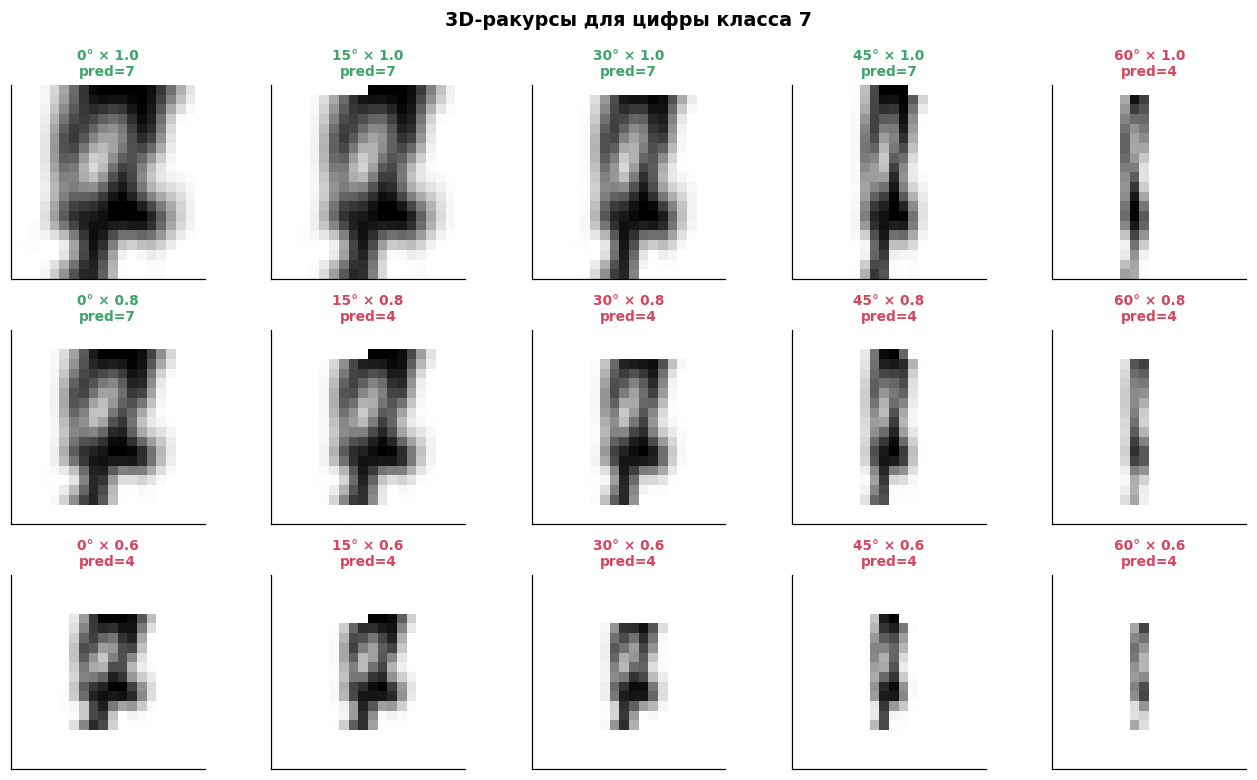

In [57]:
# ============================================================
# 3D-визуализация ракурсов: гомография + поверхность accuracy
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter, zoom

# ---------- 1. Пересоберём данные и модель  ----------
try:
    X_test_img, y_test, baseline
except NameError:
    SEED, RES = 123, 20
    digits = load_digits()
    raw = digits.images.astype(np.float32) / 16.0
    images = np.clip(np.asarray([
        gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw
    ]), 0, 1).astype(np.float32)
    labels = digits.target
    X_train_img, X_test_img, y_train, y_test = train_test_split(
        images, labels, test_size=0.30, stratify=labels, random_state=SEED)
    flat = lambda a: np.asarray(a).reshape(len(a), -1)
    baseline = LogisticRegression(max_iter=4000, C=0.05,
                                  random_state=SEED).fit(flat(X_train_img), y_train)

# ---------- 2. Гомография: реалистичный 3D-ракурс ----------
def perspective_view(image, angle_deg=0.0, squeeze_axis="horizontal"):
    """Плоский объект, повёрнутый в 3D вокруг вертикальной (или горизонтальной) оси."""
    h, w = image.shape
    a = np.deg2rad(angle_deg)
    squeeze = max(np.cos(a), 1e-3)          # сжатие по оси поворота
    shift = np.sin(a) * w * 0.35            # сдвиг дальнего края (перспектива)

    if squeeze_axis == "horizontal":
        src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        dst = np.float32([
            [shift,             0],
            [w * squeeze,       0],
            [w * squeeze,       h],
            [shift,             h],
        ])
    else:  # vertical
        src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        dst = np.float32([
            [0,     shift],
            [w,     shift],
            [w,     h * squeeze],
            [0,     h * squeeze],
        ])

    # гомография вручную (без cv2)
    A = []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y, -u])
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y, -v])
    A = np.asarray(A, dtype=np.float64)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    H /= H[2, 2]

    # применяем H к каждому пикселю выхода (обратное отображение)
    yy, xx = np.mgrid[0:h, 0:w]
    ones = np.ones_like(xx)
    coords = np.stack([xx, yy, ones], axis=-1).reshape(-1, 3).T   # 3 x N
    Hinv = np.linalg.inv(H)
    src_coords = Hinv @ coords
    src_coords /= src_coords[2:3, :]
    sx = src_coords[0].reshape(h, w)
    sy = src_coords[1].reshape(h, w)

    # билинейная выборка
    x0 = np.clip(np.floor(sx).astype(int), 0, w - 1)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.clip(np.floor(sy).astype(int), 0, h - 1)
    y1 = np.clip(y0 + 1, 0, h - 1)
    wx = np.clip(sx - x0, 0, 1)
    wy = np.clip(sy - y0, 0, 1)
    out = ((1 - wy) * ((1 - wx) * image[y0, x0] + wx * image[y0, x1]) +
           wy       * ((1 - wx) * image[y1, x0] + wx * image[y1, x1]))
    # всё, что вышло за пределы исходного изображения — чёрное
    mask = (sx < 0) | (sx > w - 1) | (sy < 0) | (sy > h - 1)
    out[mask] = 0.0
    return np.clip(out, 0, 1).astype(np.float32)


# ---------- 3. Сетка «угол × масштаб» ----------
angles_3d = np.arange(0, 61, 5)             # 0..60° с шагом 5°
scales_3d = np.arange(0.50, 1.21, 0.10)     # 0.50..1.20 с шагом 0.10
acc_grid = np.zeros((len(angles_3d), len(scales_3d)))

flat = lambda a: np.asarray(a).reshape(len(a), -1)

for i, a in enumerate(angles_3d):
    for j, s in enumerate(scales_3d):
        views = []
        for im in X_test_img:
            v = perspective_view(im, angle_deg=a)
            # масштаб: уменьшаем/увеличиваем и вписываем в исходный размер
            if abs(s - 1.0) > 1e-6:
                from scipy.ndimage import zoom as _zoom
                from scipy.ndimage import gaussian_filter as _gf
                z = _zoom(v, s, order=1)
                out = np.zeros_like(v)
                h, w = v.shape
                zh, zw = z.shape
                # центрируем
                r0 = max((h - zh) // 2, 0); c0 = max((w - zw) // 2, 0)
                rs = max((zh - h) // 2, 0); cs = max((zw - w) // 2, 0)
                out[r0:r0 + min(zh, h), c0:c0 + min(zw, w)] = \
                    z[rs:rs + min(zh, h), cs:cs + min(zw, w)]
                v = out
            views.append(v)
        views = np.asarray(views)
        acc_grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

print("Сетка accuracy (углы × масштабы):")
print(f"{'угол':>5} | " + " | ".join(f"×{s:.2f}" for s in scales_3d))
for i, a in enumerate(angles_3d):
    print(f"{a:>3}°  | " + " | ".join(f"{acc_grid[i, j]:5.2f}" for j in range(len(scales_3d))))


# ---------- 4. 3D-поверхность accuracy ----------
A_mesh, S_mesh = np.meshgrid(angles_3d, scales_3d, indexing="ij")

fig = plt.figure(figsize=(15, 5.5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(A_mesh, S_mesh, acc_grid, cmap="viridis",
                        edgecolor="k", linewidth=0.3, alpha=0.9)
ax1.set_xlabel("угол, °"); ax1.set_ylabel("масштаб"); ax1.set_zlabel("accuracy")
ax1.set_title("Поверхность accuracy: угол × масштаб")
ax1.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax1, shrink=0.6, label="accuracy")

# ---------- 5. 3D-облако точек с цветом по accuracy ----------
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
A_flat = A_mesh.ravel(); S_flat = S_mesh.ravel(); Z_flat = acc_grid.ravel()
sc = ax2.scatter(A_flat, S_flat, Z_flat, c=Z_flat, cmap="plasma",
                 s=25, depthshade=True)
ax2.set_xlabel("угол, °"); ax2.set_ylabel("масштаб"); ax2.set_zlabel("accuracy")
ax2.set_title("Облако точек: каждая точка — режим съёмки")
ax2.view_init(elev=20, azim=-55)
fig.colorbar(sc, ax=ax2, shrink=0.6, label="accuracy")

fig.suptitle("3D-взгляд на ракурсы: гомография вместо плоского поворота",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ---------- 6. Примеры искажений для одной цифры ----------
example_idx = 9
example_im = X_test_img[example_idx]
true_lab = y_test[example_idx]

demo_angles = [0, 15, 30, 45, 60]
demo_scales = [1.0, 0.8, 0.6]

fig, axes = plt.subplots(len(demo_scales), len(demo_angles),
                         figsize=(2.4 * len(demo_angles), 2.4 * len(demo_scales)))
for i, s in enumerate(demo_scales):
    for j, a in enumerate(demo_angles):
        v = perspective_view(example_im, angle_deg=a)
        if abs(s - 1.0) > 1e-6:
            from scipy.ndimage import zoom as _zoom
            z = _zoom(v, s, order=1)
            out = np.zeros_like(v)
            h, w = v.shape; zh, zw = z.shape
            r0 = max((h - zh) // 2, 0); c0 = max((w - zw) // 2, 0)
            rs = max((zh - h) // 2, 0); cs = max((zw - w) // 2, 0)
            out[r0:r0 + min(zh, h), c0:c0 + min(zw, w)] = \
                z[rs:rs + min(zh, h), cs:cs + min(zw, w)]
            v = out
        pred = int(baseline.predict(flat(v[None, ...]))[0])
        ax = axes[i, j]
        ax.imshow(v, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ok = pred == true_lab
        ax.set_title(f"{a}° × {s:.1f}\npred={pred}",
                     fontsize=9, fontweight="bold",
                     color="#3FA46A" if ok else "#D6455F")
fig.suptitle(f"3D-ракурсы для цифры класса {true_lab}",
             fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()